In [174]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import keras
from keras import layers
import numpy as np
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from keras import models
from IPython import display
import scipy.io.wavfile

import pandas as pd
from scipy.signal import resample

keras.utils.set_random_seed(41)

In [175]:
BASE_DATA_DIR = "./datasets/"
BATCH_SIZE = 16
NUM_CLASSES = 8
EPOCHS = 500
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [176]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='datasets',
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    seed=41,
    output_sequence_length=OUT_SEQ_LEN,
    label_mode = 'int',
    subset='both')

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)


Found 4240 files belonging to 8 classes.
Using 3392 files for training.
Using 848 files for validation.

label names: ['angry' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprised']


In [177]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)


In [178]:
def plot_single_spectrogram(sample_wav_data):
    # stftspec = layers.STFTSpectrogram(
    #     mode="log",
    #     frame_length=SAMPLE_RATE * 20 // 1000,
    #     frame_step=SAMPLE_RATE * 5 // 1000,
    #     fft_length=1024,
    #     trainable=False,
    # )(sample_wav_data)[0, ...]
    # # )(wav)
    # # Plot the spectrogram
    # plt.imshow(stftspec, origin="lower")
    # plt.title("Single Channel Spectrogram")
    # plt.xlabel("Time")
    # plt.ylabel("Frequency")
    # plt.show()
    melspec = layers.MelSpectrogram(
        num_mel_bins=256,
        # sequence_stride=32,
        # sampling_rate=SAMPLE_RATE,
        # sequence_stride=SAMPLE_RATE * 5 // 1000,
        sampling_rate= SAMPLE_RATE,
        sequence_stride= 256,
        fft_length=2048,
        # power_to_db=True
        
    # )(stftspec)
    )(keras.ops.reshape(sample_wav_data,[16,-1]))
    print(melspec.shape)
    plt.imshow(melspec[1], origin="lower")
    plt.title("Single Channel Spectrogram")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

(16, 72000, 1)
(16, 256, 282)


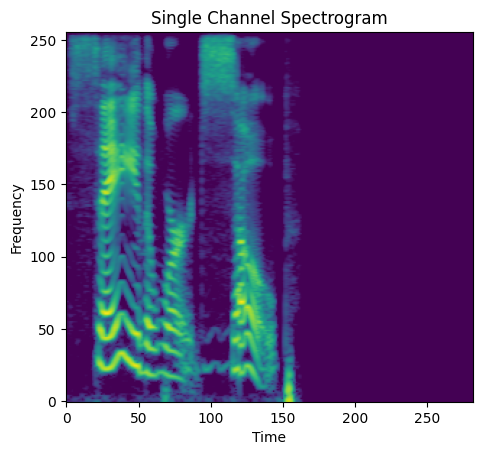

In [179]:
for t in train_ds.take(1):
    print(t[0].shape)
    plot_single_spectrogram(t[0])

In [190]:
# keras.backend.clear_session(free_memory=True)
# incv3 = keras.applications.InceptionV3(weights='imagenet',include_top=False,input_shape=(256,282,3),pooling='max')
# model_mel= keras.Sequential(
#     [
#         layers.InputLayer(shape=(OUT_SEQ_LEN,1)),
#         layers.MelSpectrogram(
#             num_mel_bins=256,
#             # sequence_stride=32,
#             # sampling_rate=SAMPLE_RATE,
#             # sequence_stride=SAMPLE_RATE * 5 // 1000,
#             sampling_rate= SAMPLE_RATE,
#             sequence_stride= 256,
#             fft_length=2048,
#         ),
#         layers.Reshape((256, 282, 1), input_shape=(256, 282)),
#         # tf.keras.layers.Lambda(tf.image.grayscale_to_rgb),
#         incv3,
#         # layers.Conv2D(64,64,8,activation='relu')
#         # layers.Conv1D(64, 8, activation="relu"),
#         # layers.Conv1D(128, 16, activation="relu"),
#         # layers.LayerNormalization(),
#         # # layers.MaxPooling1D(4),
#         # layers.Conv1D(128, 8, activation="relu"),
#         # layers.Conv1D(256, 16, padding='same', activation="relu"),
#         # layers.Conv1D(512, 64, padding='same', activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
#         # layers.LayerNormalization(),
#         # layers.MaxPooling1D(4),        
#         # # layers.LayerNormalization(),
#         # layers.Dropout(0.5),
#         # layers.GlobalMaxPooling1D(),
#         layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
#         layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05)),
#         layers.Dropout(0.5),
#         layers.Dense(NUM_CLASSES, activation="softmax"),
#     ],
#     name="model_mel",
# )


In [191]:

# input = layers.Input(shape=(OUT_SEQ_LEN,1))
# mel1 = layers.MelSpectrogram(
#             num_mel_bins=256,
#             # sequence_stride=32,
#             # sampling_rate=SAMPLE_RATE,
#             # sequence_stride=SAMPLE_RATE * 5 // 1000,
#             sampling_rate= SAMPLE_RATE,
#             sequence_stride= 128,
#             fft_length=1024,
#         )(input)
# mel1r = layers.Reshape((256, 563, 1))(mel1)
# mel2 = layers.MelSpectrogram(
#             num_mel_bins=256,
#             # sequence_stride=32,
#             # sampling_rate=SAMPLE_RATE,
#             # sequence_stride=SAMPLE_RATE * 5 // 1000,
#             sampling_rate= SAMPLE_RATE,
#             sequence_stride= 128,
#             fft_length=1024,
#         )(input)
# mel2r = layers.Reshape((256, 563, 1))(mel2)
# mel3 = layers.MelSpectrogram(
#             num_mel_bins=256,
#             # sequence_stride=32,
#             # sampling_rate=SAMPLE_RATE,
#             # sequence_stride=SAMPLE_RATE * 5 // 1000,
#             sampling_rate= SAMPLE_RATE,
#             sequence_stride= 128,
#             fft_length=1024,
#         )(input)
# mel3r = layers.Reshape((256, 563, 1))(mel3)
# conc = layers.Concatenate(axis=-1)([mel1r,mel2r,mel3r])
# incv3 = keras.applications.InceptionV3(weights='imagenet',include_top=False,input_shape=(256,563,3),pooling='max')(conc)
# dense1 = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05))(incv3)
# dense2 =layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.L1L2(l1=0.05))(dense1)
# output = layers.Dense(NUM_CLASSES, activation="softmax")(dense2)

# model_mel = keras.Model(input,output,name='mel_train')

# model_mel.compile(
#     optimizer=keras.optimizers.AdamW(1e-5),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"],
# )
# model_mel.summary()

In [205]:
# input = layers.Input((None, 1))
# spec = layers.STFTSpectrogram(
#         mode="log",
#         frame_length=SAMPLE_RATE * 40 // 1000,
#         frame_step=SAMPLE_RATE * 15 // 1000,
#         fft_length=2048,
#         padding="same",
#         expand_dims=True,
#         # trainable=True,  # trainable by default
#     )(input)
# mel = layers.MelSpectrogram(
#             num_mel_bins=256,
#             # sequence_stride=32,
#             # sampling_rate=SAMPLE_RATE,
#             # sequence_stride=SAMPLE_RATE * 5 // 1000,
#             sampling_rate= SAMPLE_RATE,
#             sequence_stride= 128,
#             fft_length=1024,
#         )(spec)
# print(mel.shape)


input = layers.Input((None, 1))
spectrograms = [
    layers.STFTSpectrogram(
        mode="log",
        frame_length=SAMPLE_RATE * frame_size // 1000,
        frame_step=SAMPLE_RATE * 15 // 1000,
        fft_length=2048,
        padding="same",
        expand_dims=True,
        # trainable=True,  # trainable by default
    )(input)
    for frame_size in [30, 40, 50]  # frame size in milliseconds
]

multi_spectrograms = layers.Concatenate(axis=-1)(spectrograms)

img_model = keras.applications.InceptionV3(include_top=False, pooling="max")
output = img_model(multi_spectrograms)

output = layers.Dropout(0.5)(output)
output = layers.Dense(256, activation="relu")(output)
output = layers.Dense(256, activation="relu")(output)
output = layers.Dense(NUM_CLASSES, activation="softmax")(output)
model2d = keras.Model(input, output, name="model_2d_trainble_stft")

model2d.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model2d.summary()

Model: "model_2d_trainble_stft"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_46      │ (None, None, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_27 │ (None, None,      │    984,000 │ input_layer_46[0… │
│ (STFTSpectrogram)   │ 1025, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_28 │ (None, None,      │  1,312,000 │ input_layer_46[0… │
│ (STFTSpectrogram)   │ 1025, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_29 │ (None, None,      │  1,640,000 │ input_layer_46[0… │
│ (STFTSpectrogram)   │ 1025, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_54      │ (None, None,      │          0 │ stft_spectrogram… │
│ (Concatenate)       │ 1025, 3)          │            │ stft_spectrogram… │
│                     │                   │            │ stft_spectrogram… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_v3        │ (None, 2048)      │ 21,802,784 │ concatenate_54[0… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ inception_v3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │    524,544 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     65,792 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 8)         │      2,056 │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,331,176 (100.45 MB)

 Trainable params: 26,296,744 (100.31 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [206]:
history_model2d = model2d.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )
    ],
)

Epoch 1/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 79s 159ms/step - accuracy: 0.4976 - loss: 1.6489 - val_accuracy: 0.6611 - val_loss: 1.0393
Epoch 2/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 30s 142ms/step - accuracy: 0.7901 - loss: 0.5926 - val_accuracy: 0.7837 - val_loss: 0.7162
Epoch 3/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 30s 142ms/step - accuracy: 0.8299 - loss: 0.4862 - val_accuracy: 0.8341 - val_loss: 0.4920
Epoch 4/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - accuracy: 0.8662 - loss: 0.3812 - val_accuracy: 0.8317 - val_loss: 0.5244
Epoch 5/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - accuracy: 0.8974 - loss: 0.3020 - val_accuracy: 0.7981 - val_loss: 0.6046
Epoch 6/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - accuracy: 0.9098 - loss: 0.2729 - val_accuracy: 0.8486 - val_loss: 0.5524
Epoch 7/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - accuracy: 0.9292 - loss: 0.2066 - val_accuracy: 0.8197 - val_loss: 0.6941
Epoch 8/500
212/212 ━━━━━━━━━━━━━━━━━━━━ 30s 142ms/step - accuracy: 0.9413 -

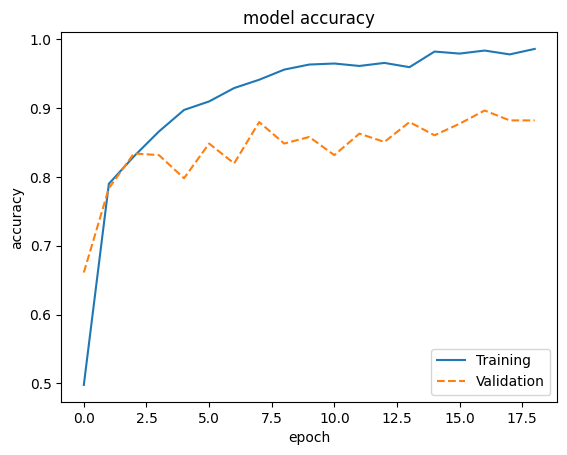

In [208]:
plt.plot(history_model2d.history['accuracy'])
plt.plot(history_model2d.history['val_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [209]:
model2d.evaluate(test_ds)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8889 - loss: 0.3766


[0.3765673041343689, 0.8888888955116272]